In [1]:
!pip install nltk scikit-learn

In [2]:
import nltk

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

print("Libraries Installed Successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Libraries Installed Successfully


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
import random
import re
import string

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [4]:
KNOWLEDGE_BASE = [
{
    "tag": "greeting",
    "patterns": [
        "hello","hi","hey","good morning",
        "good afternoon","good evening","howdy"
    ],
    "responses": [
        "Hello! Welcome to CollegeBot. How can I help you today?",
        "Hi there! I am CollegeBot. Ask me anything about the college!",
        "Hey! Great to see you. What would you like to know?"
    ]
},
{
    "tag": "farewell",
    "patterns": [
        "bye","goodbye","see you","take care",
        "quit","exit"
    ],
    "responses":[
        "Goodbye! Best of luck with your studies!",
        "See you later!",
        "Take care!"
    ]
},
{
    "tag": "admission",
    "patterns": [
        "how to apply","admission process","how can i get admission",
        "how do i join","registration process","enrollment process"
    ],
    "responses": [
        "To apply, visit our official website and fill out the online application form. You will need your 12th marksheet, ID proof, and passport photo.",
        "Admissions open every June. Complete the application form and submit all required documents before the deadline."
    ]
},

{
    "tag": "fees",
    "patterns": [
        "fees","fee structure","tuition fees","course fee",
        "semester fees","annual fees","how much is the fee"
    ],
    "responses": [
        "Engineering: ₹80,000/year, Commerce: ₹40,000/year, Science: ₹45,000/year. Scholarships are available for eligible students."
    ]
},

{
    "tag": "courses",
    "patterns": [
        "courses","programs","departments","degrees","subjects"
    ],
    "responses": [
        "We offer B.Tech, BCA, BBA, B.Sc, B.Com, BA, MBA and MCA programs."
    ]
},
{
    "tag": "hostel",
    "patterns": [
        "hostel","accommodation","stay","room","dormitory"
    ],
    "responses": [
        "Yes! Separate hostels are available for boys and girls. Monthly charges are ₹6,000 including meals."
    ]
},

{
    "tag": "placements",
    "patterns": [
        "placement","job","salary","package","career","recruitment"
    ],
    "responses": [
        "Our placement rate is 92%. Top recruiters include Infosys, TCS, Wipro, Amazon and Accenture."
    ]
},

{
    "tag": "thanks",
    "patterns": [
        "thanks","thank you","awesome","great","helpful"
    ],
    "responses": [
        "You're welcome! Feel free to ask more questions.",
        "Happy to help!"
    ]
},

{
    "tag": "unknown",
    "patterns": [],
    "responses": [
        "I'm sorry, I didn't understand that. Please ask about admissions, fees, courses, hostel or placements."
    ]
}
]

In [5]:
def preprocess(text):
    """
    Clean and normalize user input.
    """

    text = text.lower()

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    text = text.strip()

    text = " ".join(text.split())

    return text


# Test
print(preprocess("Hello!!!"))
print(preprocess(" WHAT ARE FEES? "))
print(preprocess("Good Morning :)"))

hello
what are fees
good morning


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("NLP Libraries Imported Successfully!")

NLP Libraries Imported Successfully!


In [7]:
training_sentences = [
    "hello",
    "hi",
    "hey",
    "good morning",
    "admission process",
    "how to apply",
    "college fees",
    "fee structure",
    "hostel facility",
    "accommodation",
    "courses offered",
    "available programs",
    "placements",
    "job opportunities",
    "thank you",
    "thanks",
    "bye",
    "goodbye",
    "good day",
    "greetings",
    "nice to meet you",
    "tuition fee",
    "course fee",
    "how much is the fee",
    "hostel room",
    "college hostel",
    "where is hostel",
    "available courses",
    "degree programs",
    "what programs do you offer",
    "good afternoon",
    "good evening",
    "howdy",
    "see you",
    "take care",
    "exit",
    "quit",
    "join college",
    "college admission",
    "admission date",
    "admission eligibility",
    "apply online",
    "application form",
    "engineering fees",
    "mba fees",
    "bca fees",
    "hostel fees",
    "mess facility",
    "boys hostel",
    "girls hostel",
    "hostel available",
    "btech course",
    "mba course",
    "bca course",
    "mca course",
    "computer science",
    "placement record",
    "placement companies",
    "highest package",
    "average package",
    "internships",
    "campus placement",
    "thank you so much",
    "many thanks",
    "thanks a lot",
    "appreciate it",
    "help me",
    "can you help",
    "support"
]

training_tags = [
    "greeting",
    "greeting",
    "greeting",
    "greeting",
    "admission",
    "admission",
    "fees",
    "fees",
    "hostel",
    "hostel",
    "courses",
    "courses",
    "placements",
    "placements",
    "thanks",
    "thanks",
    "farewell",
    "farewell",
    "greeting",
    "greeting",
    "greeting",
    "fees",
    "fees",
    "fees",
    "hostel",
    "hostel",
    "hostel",
    "courses",
    "courses",
    "courses",
    "greeting",
    "greeting",
    "greeting",
    "greeting",

    "farewell",
    "farewell",
    "farewell",
    "farewell",

    "admission",
    "admission",
    "admission",
    "admission",
    "admission",

    "fees",
    "fees",
    "fees",
    "fees",

    "hostel",
    "hostel",
    "hostel",
    "hostel",

    "courses",
    "courses",
    "courses",
    "courses",
    "courses",

    "placements",
    "placements",
    "placements",
    "placements",
    "placements",
    "placements",

    "thanks",
    "thanks",
    "thanks",
    "thanks",

    "greeting",
    "greeting",
    "greeting"
]

print("Training Data Ready!")

Training Data Ready!


In [8]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(training_sentences)

print("TF-IDF Model Created Successfully!")
print("Shape:", X.shape)

TF-IDF Model Created Successfully!
Shape: (69, 85)


In [9]:
def nlp_chatbot(user_input):

    user_input = preprocess(user_input)

    user_vector = vectorizer.transform([user_input])

    similarity = cosine_similarity(user_vector, X)

    index = similarity.argmax()

    score = similarity[0][index]

    if score < 0.20:
        return "Sorry, I couldn't understand your question."

    tag = training_tags[index]

    for entry in KNOWLEDGE_BASE:

        if entry["tag"] == tag:
            return random.choice(entry["responses"])

In [10]:
print(nlp_chatbot("hello"))
print(nlp_chatbot("How do I apply?"))
print(nlp_chatbot("Tell me hostel details"))
print(nlp_chatbot("What are the fees?"))
print(nlp_chatbot("Placement"))
print(nlp_chatbot("Thanks"))
print(nlp_chatbot("Bye"))

Hello! Welcome to CollegeBot. How can I help you today?
To apply, visit our official website and fill out the online application form. You will need your 12th marksheet, ID proof, and passport photo.
Hey! Great to see you. What would you like to know?
Engineering: ₹80,000/year, Commerce: ₹40,000/year, Science: ₹45,000/year. Scholarships are available for eligible students.
Our placement rate is 92%. Top recruiters include Infosys, TCS, Wipro, Amazon and Accenture.
You're welcome! Feel free to ask more questions.
Goodbye! Best of luck with your studies!


In [11]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english")) - {
    "not", "no", "never", "very", "too"
}

def advanced_preprocess(text):
    # Convert to lowercase
    text = text.lower()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove punctuation
    tokens = [t for t in tokens if t.isalpha()]

    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Join words
    return " ".join(tokens)

In [13]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [14]:
print(advanced_preprocess("Hello, How are You?"))
print(advanced_preprocess("Running students are studying"))
print(advanced_preprocess("What are the fees for Engineering?"))
print(advanced_preprocess("I need information about hostel"))

hello
running student studying
fee engineering
need information hostel


In [15]:
X_raw = []
y = []

for entry in KNOWLEDGE_BASE:
    if entry["tag"] == "unknown":
        continue

    for pattern in entry["patterns"]:
        X_raw.append(pattern)
        y.append(entry["tag"])

print("Total Training Patterns:", len(X_raw))

for i in range(min(10, len(X_raw))):
    print(f"{i+1}. {X_raw[i]} --> {y[i]}")

Total Training Patterns: 47
1. hello --> greeting
2. hi --> greeting
3. hey --> greeting
4. good morning --> greeting
5. good afternoon --> greeting
6. good evening --> greeting
7. howdy --> greeting
8. bye --> farewell
9. goodbye --> farewell
10. see you --> farewell


In [16]:
X_proc = []

for sentence in training_sentences:
    X_proc.append(advanced_preprocess(sentence))

print("Preprocessed Sentences Created Successfully!")
print("Total Sentences:", len(X_proc))

for i in range(10):
    print(training_sentences[i], " --> ", X_proc[i])

Preprocessed Sentences Created Successfully!
Total Sentences: 69
hello  -->  hello
hi  -->  hi
hey  -->  hey
good morning  -->  good morning
admission process  -->  admission process
how to apply  -->  apply
college fees  -->  college fee
fee structure  -->  fee structure
hostel facility  -->  hostel facility
accommodation  -->  accommodation


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

vectorizer = TfidfVectorizer(ngram_range=(1,2))

X = vectorizer.fit_transform(X_proc)

model = LogisticRegression(max_iter=2000)

model.fit(X, training_tags)

print("TF-IDF Vectorizer Created Successfully!")
print("Logistic Regression Model Trained Successfully!")
print("Shape:", X.shape)

TF-IDF Vectorizer Created Successfully!
Logistic Regression Model Trained Successfully!
Shape: (69, 118)


In [18]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X)

accuracy = accuracy_score(training_tags, predictions)

print("Model Accuracy:", accuracy * 100, "%")

Model Accuracy: 100.0 %


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X_proc)

model = LogisticRegression(max_iter=1000)

model.fit(X, training_tags)

print("TF-IDF Vectorizer Created Successfully!")
print("Logistic Regression Model Trained Successfully!")
print("Shape:", X.shape)

TF-IDF Vectorizer Created Successfully!
Logistic Regression Model Trained Successfully!
Shape: (69, 70)


In [20]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X)

accuracy = accuracy_score(training_tags, predictions)

print("Model Accuracy:", accuracy * 100, "%")

Model Accuracy: 100.0 %


In [21]:
def predict_intent(user_input):
    processed = advanced_preprocess(user_input)
    vector = vectorizer.transform([processed])
    prediction = model.predict(vector)[0]
    return prediction

In [22]:
print("Sentence 1:", predict_intent("Hello"))
print("Sentence 2:", predict_intent("How do I apply for admission?"))
print("Sentence 3:", predict_intent("Tell me about hostel facilities"))
print("Sentence 4:", predict_intent("What is the engineering fee?"))
print("Sentence 5:", predict_intent("Thank you very much"))

Sentence 1: greeting
Sentence 2: admission
Sentence 3: hostel
Sentence 4: fees
Sentence 5: thanks


In [23]:
def chatbot():

    print("=" * 50)
    print("🤖 CollegeBot - NLP AI Assistant")
    print("Type 'bye' to exit.")
    print("=" * 50)

    while True:

        user_input = input("\nYou : ")

        if user_input.lower() == "bye":
            print("Bot : Goodbye! Best of luck with your studies!")
            break

        intent = predict_intent(user_input)

        found = False

        for entry in KNOWLEDGE_BASE:
            if entry["tag"] == intent:
                print("Bot :", entry["responses"][0])
                found = True
                break

        if not found:
            print("Bot : Sorry! I couldn't understand your question.")

In [25]:
chatbot()

🤖 CollegeBot - NLP AI Assistant
Type 'bye' to exit.

You : Hi!
Bot : Hello! Welcome to CollegeBot. How can I help you today?

You : Can you tell me about fee structure?
Bot : Engineering: ₹80,000/year, Commerce: ₹40,000/year, Science: ₹45,000/year. Scholarships are available for eligible students.

You : Hostel facilities?
Bot : Yes! Separate hostels are available for boys and girls. Monthly charges are ₹6,000 including meals.

You : Placements?
Bot : Our placement rate is 92%. Top recruiters include Infosys, TCS, Wipro, Amazon and Accenture.

You : Thanks you!
Bot : You're welcome! Feel free to ask more questions.

You : Bye
Bot : Goodbye! Best of luck with your studies!


In [26]:
import pickle

with open("chatbot_tfidf.pkl", "wb") as file:
    pickle.dump((vectorizer, model), file)

print("Model Saved Successfully!")

Model Saved Successfully!


<Figure size 1600x600 with 0 Axes>

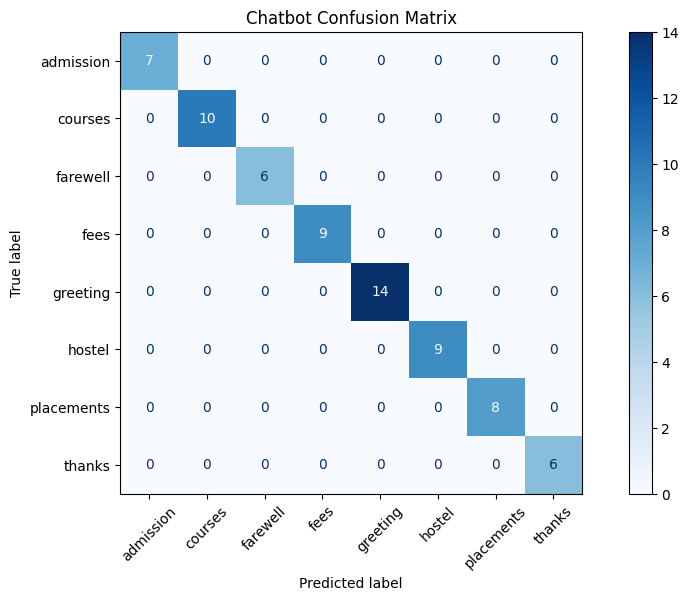

Confusion Matrix Saved Successfully!


In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = model.predict(X)

cm = confusion_matrix(training_tags, predictions)

# Increase figure size (Width, Height)
plt.figure(figsize=(16, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Chatbot Confusion Matrix")
plt.gcf().set_size_inches(12, 6)   # Horizontal size
plt.savefig("chatbot_confusion_matrix.png", dpi=300)
plt.show()

print("Confusion Matrix Saved Successfully!")

In [28]:
from google.colab import files
files.download("chatbot_tfidf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
from google.colab import files
files.download("chatbot_confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>